In [1]:
%%time
import sys, os
path_dir = os.getcwd()
sys.path.append(path_dir+"/Functions")
from General_functions import *
from Input_func import *
from IO_Plots import *
from PC_Plots import *
from DCN_Plots import *
from New_func import *
from Raster_hist_plots import *
from read_data import *
start_scope()
###################################################################
######################### Load Parameters #########################
###################################################################
# Name_BCM = "Learned_BCM"
# time_now_BCM = "09:15"
# Name_No_BCM = "No_BCM"
# time_now_No_BCM = "09:47"
# date = "06-07"
Name_BCM = "Learned_BCM"
time_now_BCM = "21:54"
Name_No_BCM = "No_BCM"
time_now_No_BCM = "15:10"
date = "06-10"
Frozen_data = sio.loadmat('Data/'+date+'/Frozen.mat', squeeze_me=True)
Params, Noise_frozen, Values, Synapses = Read_Input(Frozen_data)
###################################################################
############################ Load Data ############################
###################################################################
Output_Noise_No_BCM, Output_Noise_Extended_No_BCM, Output_PC_No_BCM, Output_DCN_No_BCM, Output_IO_No_BCM, Output_mon_N_PC_No_BCM, Output_Noise_Coupled_No_BCM, Output_Noise_Extended_Coupled_No_BCM, Output_PC_Coupled_No_BCM, Output_DCN_Coupled_No_BCM, Output_IO_Coupled_No_BCM, Output_mon_N_PC_Coupled = load_data(Name_No_BCM, time_now_No_BCM, date)
Output_Noise_BCM, Output_Noise_Extended_BCM, Output_PC_BCM, Output_DCN_BCM, Output_IO_BCM, Output_mon_N_PC_BCM, Output_Noise_Coupled_BCM, Output_Noise_Extended_Coupled_BCM, Output_PC_Coupled_BCM, Output_DCN_Coupled_BCM, Output_IO_Coupled_BCM, Output_mon_N_PC_Coupled = load_data(Name_BCM, time_now_BCM, date)
###################################################################
########################### Load Cells ############################
###################################################################
Noise_BCM, Noise_Extended_BCM, PC_BCM, DCN_BCM, IO_BCM, mon_N_PC_BCM = Output_func(Name_BCM,"",Output_Noise_BCM, Output_Noise_Extended_BCM, Output_PC_BCM, Output_DCN_BCM, Output_IO_BCM, Output_mon_N_PC_BCM, Output_Noise_Coupled_BCM, Output_Noise_Extended_Coupled_BCM, Output_PC_Coupled_BCM, Output_DCN_Coupled_BCM, Output_IO_Coupled_BCM, Output_mon_N_PC_Coupled)
Noise_Coupled_BCM, Noise_Extended_Coupled_BCM, PC_Coupled_BCM, DCN_Coupled_BCM, IO_Coupled_BCM, mon_N_PC_Coupled_BCM = Output_func(Name_BCM,"Coupled",Output_Noise_BCM, Output_Noise_Extended_BCM, Output_PC_BCM, Output_DCN_BCM, Output_IO_BCM, Output_mon_N_PC_BCM, Output_Noise_Coupled_BCM, Output_Noise_Extended_Coupled_BCM, Output_PC_Coupled_BCM, Output_DCN_Coupled_BCM, Output_IO_Coupled_BCM, Output_mon_N_PC_Coupled)
time_x_BCM = Noise_BCM.t

Noise_No_BCM, Noise_Extended_No_BCM, PC_No_BCM, DCN_No_BCM, IO_No_BCM, mon_N_PC_No_BCM = Output_func(Name_No_BCM,"",Output_Noise_No_BCM, Output_Noise_Extended_No_BCM, Output_PC_No_BCM, Output_DCN_No_BCM, Output_IO_No_BCM, Output_mon_N_PC_No_BCM, Output_Noise_Coupled_No_BCM, Output_Noise_Extended_Coupled_No_BCM, Output_PC_Coupled_No_BCM, Output_DCN_Coupled_No_BCM, Output_IO_Coupled_No_BCM, Output_mon_N_PC_Coupled)
Noise_Coupled_No_BCM, Noise_Extended_Coupled_No_BCM, PC_Coupled_No_BCM, DCN_Coupled_No_BCM, IO_Coupled_No_BCM, mon_N_PC_Coupled_No_BCM = Output_func(Name_No_BCM,"Coupled",Output_Noise_No_BCM, Output_Noise_Extended_No_BCM, Output_PC_No_BCM, Output_DCN_No_BCM, Output_IO_No_BCM, Output_mon_N_PC_No_BCM, Output_Noise_Coupled_No_BCM, Output_Noise_Extended_Coupled_No_BCM, Output_PC_Coupled_No_BCM, Output_DCN_Coupled_No_BCM, Output_IO_Coupled_No_BCM, Output_mon_N_PC_Coupled)
time_x_No_BCM = Noise_No_BCM.t

step1 = 550
step = int(step1/(Params.dt_rec/msecond))
xx = range(-step,step)
xx1 = [item * (Params.dt_rec/msecond) for item in xx]
half = int(time_x_BCM[len(time_x_BCM)//2]/1000)

CPU times: user 8.94 s, sys: 16 s, total: 24.9 s
Wall time: 27.6 s


In [2]:
# x = PC_No_BCM.rate
# y = PC_BCM.rate[len(PC_BCM.rate)//2:]
# lags = 5000#int(len(PC_No_BCM.rate)-1)

# fig = plt.figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
# xcorr(x, y, maxlags=lags, normed=True)
# grid(True)
# plt.xlim([-int(1/(Params.dt_rec/second)),int(1/(Params.dt_rec/second))])
# plt.ylim([0,1])
# plt.show()

Text(0.5, 1.0, 'Before and after BCM firing frequencies PC (Coupled)')

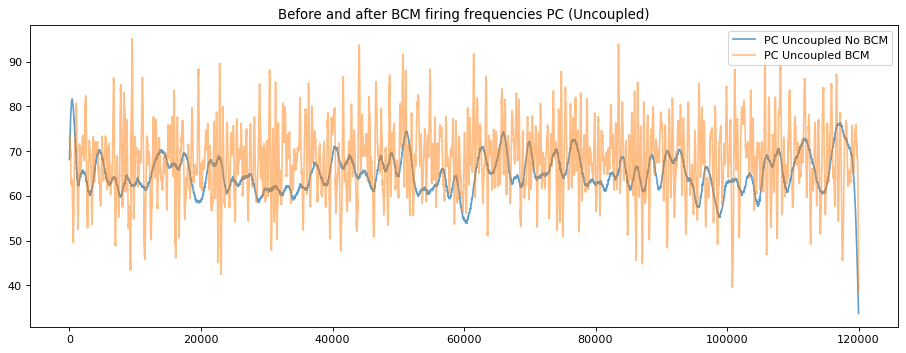

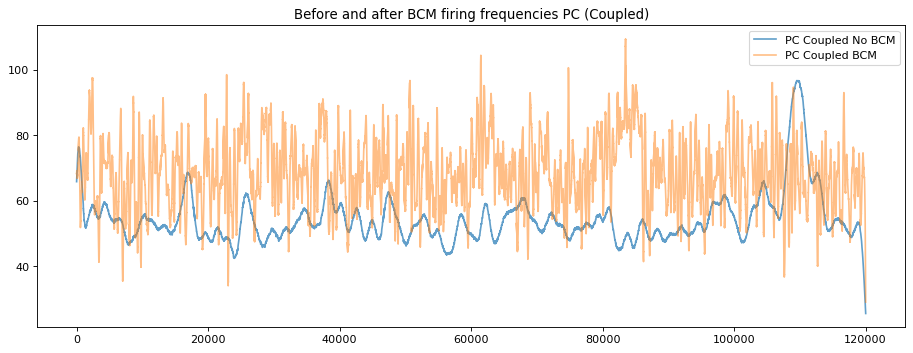

In [3]:
plt.figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
plot(PC_No_BCM.rate_time,PC_No_BCM.rate, label='PC Uncoupled No BCM', alpha=0.7)
plot(PC_No_BCM.rate_time,PC_BCM.rate[len(PC_BCM.rate)//2:], label='PC Uncoupled BCM', alpha=0.5)
legend(loc='upper right')
title('Before and after BCM firing frequencies PC (Uncoupled)')

plt.figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
plot(PC_No_BCM.rate_time,PC_Coupled_No_BCM.rate, label='PC Coupled No BCM', alpha=0.7)
plot(PC_No_BCM.rate_time,PC_Coupled_BCM.rate[len(PC_Coupled_BCM.rate)//2:], label='PC Coupled BCM', alpha=0.5)
legend(loc='upper right')
title('Before and after BCM firing frequencies PC (Coupled)')

Text(0.5, 1.0, 'Before and after BCM firing frequencies DCN (Coupled)')

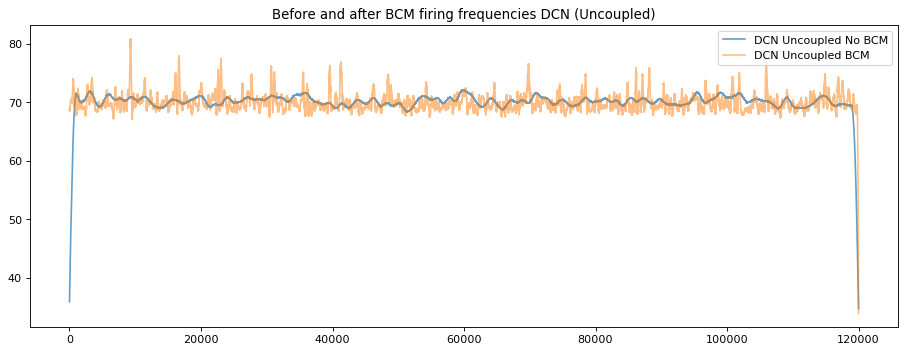

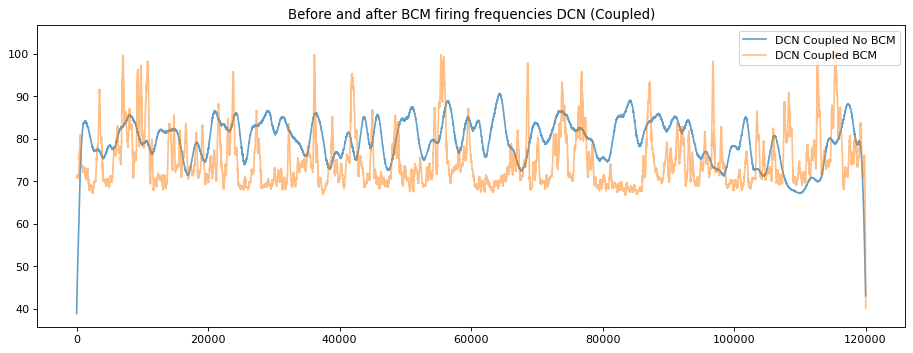

In [4]:
plt.figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
plot(PC_No_BCM.rate_time,DCN_No_BCM.rate, label='DCN Uncoupled No BCM', alpha=0.7)
plot(PC_No_BCM.rate_time,DCN_BCM.rate[len(DCN_BCM.rate)//2:], label='DCN Uncoupled BCM', alpha=0.5)
legend(loc='upper right')
title('Before and after BCM firing frequencies DCN (Uncoupled)')

plt.figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
plot(PC_No_BCM.rate_time,DCN_Coupled_No_BCM.rate, label='DCN Coupled No BCM', alpha=0.7)
plot(PC_No_BCM.rate_time,DCN_Coupled_BCM.rate[len(DCN_Coupled_BCM.rate)//2:], label='DCN Coupled BCM', alpha=0.5)
legend(loc='upper right')
title('Before and after BCM firing frequencies DCN (Coupled)')

Text(0.5, 1.0, 'Before and after BCM firing frequencies IO (Coupled)')

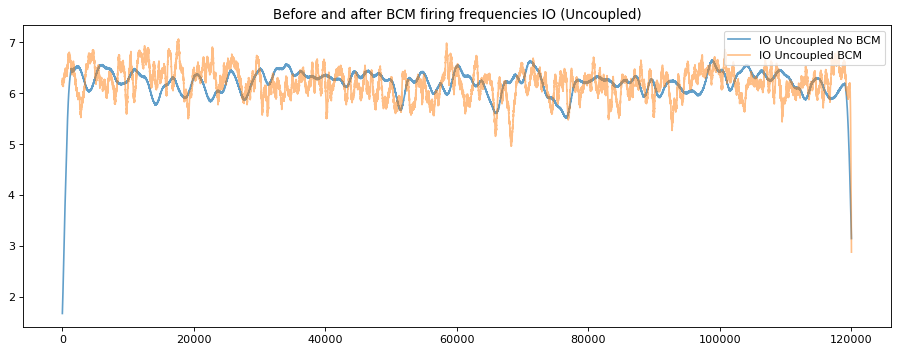

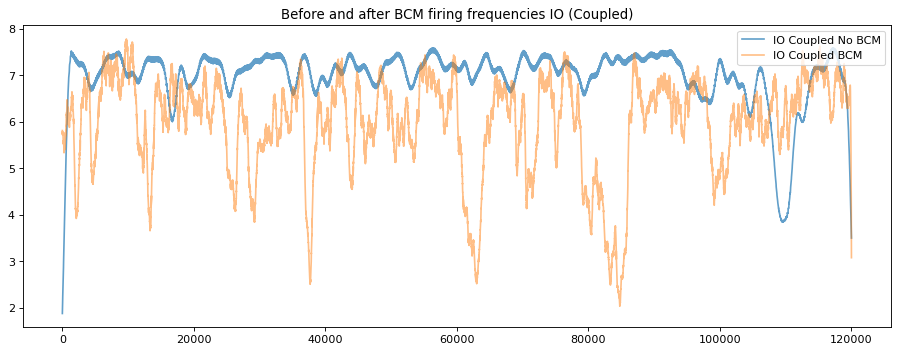

In [5]:
plt.figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
plot(PC_No_BCM.rate_time,IO_No_BCM.rate, label='IO Uncoupled No BCM', alpha=0.7)
plot(PC_No_BCM.rate_time,IO_BCM.rate[len(IO_BCM.rate)//2:], label='IO Uncoupled BCM', alpha=0.5)
legend(loc='upper right')
title('Before and after BCM firing frequencies IO (Uncoupled)')

plt.figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
plot(PC_No_BCM.rate_time,IO_Coupled_No_BCM.rate, label='IO Coupled No BCM', alpha=0.7)
plot(PC_No_BCM.rate_time,IO_Coupled_BCM.rate[len(DCN_Coupled_BCM.rate)//2:], label='IO Coupled BCM', alpha=0.5)
legend(loc='upper right')
title('Before and after BCM firing frequencies IO (Coupled)')

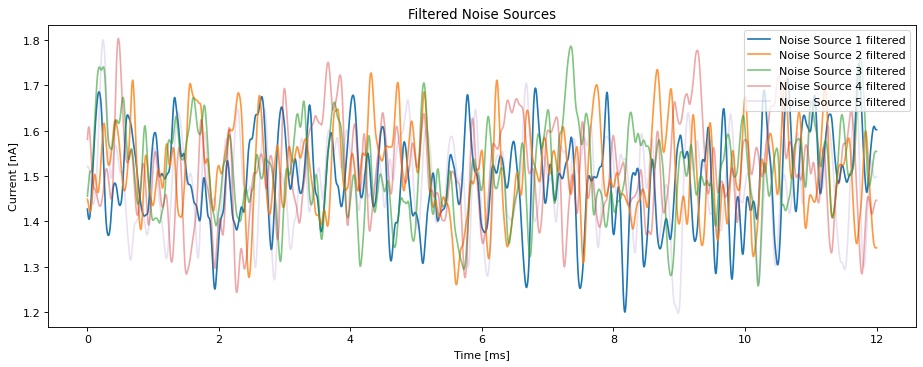

In [30]:
fs = 1/(Params.dt/second)  # Sampling frequency
plt.figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k') 
for ii in range(0,Params.N_Noise):
    t = np.arange(len(Noise_No_BCM.I[ii]))/fs
    signala = Noise_No_BCM.I[ii] # with frequency of 100
    fc = 5  # Cut-off frequency of the filter
    w = fc / (fs / 2) # Normalize the frequency
    b, a = signal.butter(2, w, 'low')
    output = signal.filtfilt(b, a, signala/nA)
    plt.plot(t, output, label="Noise Source "+str(ii+1)+' filtered', alpha=1-(ii/5))
ylabel('Current [nA]')
xlabel('Time [ms]')
title('Filtered Noise Sources')
legend(loc='upper right')
show()

In [7]:
# plt.figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
# for ii in range(0,Params.N_Noise):
#     plot(time_x_No_BCM,Noise_No_BCM.I[ii]/nA,label="Noise "+str(ii+1), alpha=(7-ii)/10)
# ylabel('V [mV]')
# xlabel('Time [ms]')
# legend(loc='upper right')
# show()

# plt.figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
# for ii in range(0,Params.N_Noise):
#     plot(time_x_BCM,Noise_Extended_BCM.I[ii]/nA,label="Noise "+str(ii+1), alpha=(7-ii)/10)
# ylabel('V [mV]')
# xlabel('Time [ms]')
# legend(loc='upper right')
# show()

In [8]:
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy import signal

# fs = 1/(Params.dt/second)  # Sampling frequency
# for ii in range(0,Params.N_Cells_PC):
#     plt.figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
# #     plot(time_x_No_BCM,mon_N_PC_No_BCM.new_weight[ii],label="new_weight "+str(ii+1))
#     for jj in range(ii*Params.N_Noise,(ii+1)*Params.N_Noise):   
#         t = np.arange(len(mon_N_PC_BCM.new_weight[jj][len(mon_N_PC_BCM.new_weight[jj])//2:]))/fs
#         signala = mon_N_PC_BCM.new_weight[jj][len(mon_N_PC_BCM.new_weight[jj])//2:] # with frequency of 100
# #         plt.plot(t, signala,label="new_weight dendrite "+str(jj+1))
#         fc = 5  # Cut-off frequency of the filter
#         w = fc / (fs / 2) # Normalize the frequency
#         b, a = signal.butter(2, w, 'low')
#         output = signal.filtfilt(b, a, signala)
#         plt.plot(t, output, label="new_weight dendrite "+str(jj+1)+' filtered')
#     ylabel('Weight [-]')
#     xlabel('Time [ms]')
#     title('Weights for PC '+str(ii+1))
#     legend(loc='upper right')
#     show()

In [9]:
# for ii in range(0,Params.N_Cells_PC):
#     plt.figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
# #     plot(time_x_No_BCM,mon_N_PC_No_BCM.new_weight[ii],label="new_weight "+str(ii+1))
#     for jj in range(ii*Params.N_Noise,(ii+1)*Params.N_Noise):
#         plot(time_x_No_BCM,mon_N_PC_BCM.new_weight[jj][len(mon_N_PC_BCM.new_weight[jj])//2:],label="new_weight dendrite "+str(jj+1))
#     ylabel('Weight [-]')
#     xlabel('Time [ms]')
#     title('Weights for PC '+str(ii+1))
#     legend(loc='upper right')
#     show()

In [10]:
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy import signal

# fs = 1/(Params.dt/second)  # Sampling frequency
# for ii in range(0,Params.N_Cells_PC):
#     plt.figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
# #     plot(time_x_No_BCM,mon_N_PC_No_BCM.new_weight[ii],label="new_weight "+str(ii+1))
#     for jj in range(ii*Params.N_Noise,(ii+1)*Params.N_Noise):   
#         t = np.arange(len(mon_N_PC_BCM.new_weight[jj]))/fs
#         signala = mon_N_PC_BCM.new_weight[jj] # with frequency of 100
# #         plt.plot(t, signala,label="new_weight dendrite "+str(jj+1))
#         fc = 5  # Cut-off frequency of the filter
#         w = fc / (fs / 2) # Normalize the frequency
#         b, a = signal.butter(2, w, 'low')
#         output = signal.filtfilt(b, a, signala)
#         plt.plot(t, output, label="new_weight dendrite "+str(jj+1)+' filtered')
#     ylabel('Weight [-]')
#     xlabel('Time [ms]')
#     title('Weights for PC '+str(ii+1))
#     legend(loc='upper right')
#     show()

In [11]:
# for ii in range(0,Params.N_Cells_PC):
#     plt.figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
#     for jj in range(ii*Params.N_Noise,(ii+1)*Params.N_Noise):
#         plot(time_x_BCM,mon_N_PC_BCM.new_weight[jj],label="new_weight dendrite "+str(jj+1))
#     ylabel('Weight [-]')
#     xlabel('Time [ms]')
#     title('Weights for PC '+str(ii+1))
#     legend(loc='upper right')
#     show()

In [12]:
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy import signal

# fs = 1/(Params.dt/second)  # Sampling frequency
# for ii in range(0,Params.N_Cells_PC):
#     plt.figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
# #     plot(time_x_No_BCM,mon_N_PC_No_BCM.new_weight[ii],label="new_weight "+str(ii+1))
#     for jj in range(ii*Params.N_Noise,(ii+1)*Params.N_Noise):   
#         t = np.arange(len(mon_N_PC_BCM.delta_weight[jj][len(mon_N_PC_BCM.delta_weight[jj])//2:]))/fs
#         signala = mon_N_PC_BCM.delta_weight[jj][len(mon_N_PC_BCM.delta_weight[jj])//2:] # with frequency of 100
# #         plt.plot(t, signala,label="new_weight dendrite "+str(jj+1))
#         fc = 5  # Cut-off frequency of the filter
#         w = fc / (fs / 2) # Normalize the frequency
#         b, a = signal.butter(2, w, 'low')
#         output = signal.filtfilt(b, a, signala)
#         plt.plot(t, output, label="delta_weight dendrite "+str(jj+1)+' filtered')
#     ylabel('Weight [-]')
#     xlabel('Time [ms]')
#     title('Weights for PC '+str(ii+1))
#     legend(loc='lower left')
#     show()

In [13]:
# for ii in range(0,Params.N_Cells_PC):
#     plt.figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
#     for jj in range(ii*Params.N_Noise,(ii+1)*Params.N_Noise):
#         plot(time_x_No_BCM,mon_N_PC_BCM.delta_weight[jj][len(mon_N_PC_BCM.delta_weight[jj])//2:],label="delta_weight dendrite "+str(jj+1))
#     ylabel('Weight [-]')
#     xlabel('Time [ms]')
#     title('Delta weights for PC '+str(ii+1))
#     legend(loc='upper right')
#     show()

In [14]:
# for ii in range(0,Params.N_Cells_PC):
#     plt.figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
#     for jj in range(ii*Params.N_Noise,(ii+1)*Params.N_Noise):
#         plot(time_x_No_BCM,mon_N_PC_BCM.rho_PC[jj][len(mon_N_PC_BCM.new_weight[jj])//2:],label="delta_weight dendrite "+str(jj+1))
#     ylabel('V [mV]')
#     xlabel('Time [ms]')
#     legend()
#     show()

# for ii in range(0,Params.N_Cells_PC):
#     plt.figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
#     for jj in range(ii*Params.N_Noise,(ii+1)*Params.N_Noise):
#         plot(time_x_No_BCM,mon_N_PC_BCM.rho_PF[jj][len(mon_N_PC_BCM.new_weight[jj])//2:],label="delta_weight dendrite "+str(jj+1))
#     ylabel('V [mV]')
#     xlabel('Time [ms]')
#     legend()
#     show()

In [15]:
# for ii in range(0,Params.N_Cells_PC):
#     for jj in range(0,Params.N_Noise):
#         plt.figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
#         plot(time_x_No_BCM,Noise_No_BCM.I[jj]/nA,label="Noise "+str(jj+1)l)
#         plot(time_x_No_BCM,PC_No_BCM.I_Noise[ii]/nA,label="PSC "+str(ii+1))
#         ylabel('I [nA]')
#         xlabel('Time [ms]')
#         legend()
#         show()

In [16]:
# ii = jj = 1
# x = Noise_No_BCM.I[jj]
# y = PC_No_BCM.I_Noise[ii]
# lags = int(len(Noise_No_BCM.I[jj])-1)

# fig = plt.figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
# xcorr(x, y, maxlags=lags, normed=True)
# grid(True)
# plt.xlim([-int(1/(Params.dt_rec/second)),int(1/(Params.dt_rec/second))])
# plt.ylim([0,1])
# plt.show()

CPU times: user 25.1 s, sys: 1.76 s, total: 26.9 s
Wall time: 27.3 s


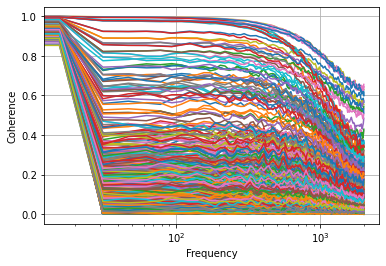

In [17]:
%%time
f_No_BCM = [[]]*Params.N_Cells_PC
f_During_BCM = [[]]*Params.N_Cells_PC
f_BCM = [[]]*Params.N_Cells_PC
f_Coupled_No_BCM = [[]]*Params.N_Cells_PC
f_Coupled_During_BCM = [[]]*Params.N_Cells_PC
f_Coupled_BCM = [[]]*Params.N_Cells_PC
cxy_No_BCM = [[]]*Params.N_Cells_PC
cxy_During_BCM = [[]]*Params.N_Cells_PC
cxy_BCM = [[]]*Params.N_Cells_PC
cxy_Coupled_No_BCM = [[]]*Params.N_Cells_PC
cxy_Coupled_During_BCM = [[]]*Params.N_Cells_PC
cxy_Coupled_BCM = [[]]*Params.N_Cells_PC
for ii in range(0,Params.N_Cells_PC):
    f_No_BCM[ii] = [[]]*Params.N_Noise
    f_During_BCM[ii] = [[]]*Params.N_Noise
    f_BCM[ii] = [[]]*Params.N_Noise
    f_Coupled_No_BCM[ii] = [[]]*Params.N_Noise
    f_Coupled_During_BCM[ii] = [[]]*Params.N_Noise
    f_Coupled_BCM[ii] = [[]]*Params.N_Noise
    cxy_No_BCM[ii] = [[]]*Params.N_Noise
    cxy_During_BCM[ii] = [[]]*Params.N_Noise
    cxy_BCM[ii] = [[]]*Params.N_Noise
    cxy_Coupled_No_BCM[ii] = [[]]*Params.N_Noise
    cxy_Coupled_During_BCM[ii] = [[]]*Params.N_Noise
    cxy_Coupled_BCM[ii] = [[]]*Params.N_Noise
    for jj in range(0,Params.N_Noise):     
        cxy_No_BCM[ii][jj], f_No_BCM[ii][jj] = cohere(PC_No_BCM.I_Noise[ii]/nA, Noise_No_BCM.I[jj]/nA, 256, 1./Params.dt_rec/second ,label="Noise "+str(jj+1))
        cxy_During_BCM[ii][jj], f_During_BCM[ii][jj] = cohere(PC_BCM.I_Noise[ii][:len(PC_BCM.I_Noise[ii])//2]/nA, Noise_Extended_BCM.I[jj][:len(Noise_Extended_BCM.I[jj])//2]/nA, 256, 1./Params.dt_rec/second ,label="Noise "+str(jj+1))
        cxy_BCM[ii][jj], f_BCM[ii][jj] = cohere(PC_BCM.I_Noise[ii][len(PC_BCM.I_Noise[ii])//2:]/nA, Noise_Extended_BCM.I[jj][len(Noise_Extended_BCM.I[jj])//2:]/nA, 256, 1./Params.dt_rec/second ,label="Noise "+str(jj+1))
        cxy_Coupled_No_BCM[ii][jj], f_Coupled_No_BCM[ii][jj] = cohere(PC_Coupled_No_BCM.I_Noise[ii]/nA, Noise_Coupled_No_BCM.I[jj]/nA, 256, 1./Params.dt_rec/second ,label="Noise "+str(jj+1))
        cxy_Coupled_During_BCM[ii][jj], f_Coupled_During_BCM[ii][jj] = cohere(PC_Coupled_BCM.I_Noise[ii][:len(PC_Coupled_BCM.I_Noise[ii])//2]/nA, Noise_Extended_Coupled_BCM.I[jj][:len(Noise_Extended_Coupled_BCM.I[jj])//2]/nA, 256, 1./Params.dt_rec/second ,label="Noise "+str(jj+1))
        cxy_Coupled_BCM[ii][jj], f_Coupled_BCM[ii][jj] = cohere(PC_Coupled_BCM.I_Noise[ii][len(PC_Coupled_BCM.I_Noise[ii])//2:]/nA, Noise_Extended_Coupled_BCM.I[jj][len(Noise_Extended_Coupled_BCM.I[jj])//2:]/nA, 256, 1./Params.dt_rec/second ,label="Noise "+str(jj+1))
    xscale('log')
    
mean_point_cxy_No_BCM = [[]]*Params.N_Cells_PC
mean_point_cxy_During_BCM = [[]]*Params.N_Cells_PC
mean_point_cxy_BCM = [[]]*Params.N_Cells_PC
mean_point_cxy_Coupled_No_BCM = [[]]*Params.N_Cells_PC
mean_point_cxy_Coupled_During_BCM = [[]]*Params.N_Cells_PC
mean_point_cxy_Coupled_BCM = [[]]*Params.N_Cells_PC
for ii in range(0,Params.N_Cells_PC):
    mean_point_cxy_No_BCM[ii] = [[]]*Params.N_Noise
    mean_point_cxy_During_BCM[ii] = [[]]*Params.N_Noise
    mean_point_cxy_BCM[ii] = [[]]*Params.N_Noise
    mean_point_cxy_Coupled_No_BCM[ii] = [[]]*Params.N_Noise
    mean_point_cxy_Coupled_During_BCM[ii] = [[]]*Params.N_Noise
    mean_point_cxy_Coupled_BCM[ii] = [[]]*Params.N_Noise
    for jj in range(0,Params.N_Noise):
        idx_aa = []
        for kk in range(0,len(f_No_BCM[ii][jj])):
            if 10**2 <= f_No_BCM[ii][jj][kk]/Hz/Hz <= 10**3:
                idx_aa.append(kk)
        mean_point_cxy_No_BCM[ii][jj] = mean(cxy_No_BCM[ii][jj][idx_aa])
        idx_aa = []
        for kk in range(0,len(f_During_BCM[ii][jj])):
            if 10**2 <= f_During_BCM[ii][jj][kk]/Hz/Hz <= 10**3:
                idx_aa.append(kk)
        mean_point_cxy_During_BCM[ii][jj] = mean(cxy_During_BCM[ii][jj][idx_aa])
        idx_aa = []
        for kk in range(0,len(f_BCM[ii][jj])):
            if 10**2 <= f_BCM[ii][jj][kk]/Hz/Hz <= 10**3:
                idx_aa.append(kk)
        mean_point_cxy_BCM[ii][jj] = mean(cxy_BCM[ii][jj][idx_aa])
        idx_aa = []
        for kk in range(0,len(f_Coupled_No_BCM[ii][jj])):
            if 10**2 <= f_Coupled_No_BCM[ii][jj][kk]/Hz/Hz <= 10**3:
                idx_aa.append(kk)
        mean_point_cxy_Coupled_No_BCM[ii][jj] = mean(cxy_Coupled_No_BCM[ii][jj][idx_aa])
        idx_aa = []
        for kk in range(0,len(f_Coupled_During_BCM[ii][jj])):
            if 10**2 <= f_Coupled_During_BCM[ii][jj][kk]/Hz/Hz <= 10**3:
                idx_aa.append(kk)
        mean_point_cxy_Coupled_During_BCM[ii][jj] = mean(cxy_Coupled_During_BCM[ii][jj][idx_aa])
        idx_aa = []
        for kk in range(0,len(f_Coupled_BCM[ii][jj])):
            if 10**2 <= f_Coupled_BCM[ii][jj][kk]/Hz/Hz <= 10**3:
                idx_aa.append(kk)
        mean_point_cxy_Coupled_BCM[ii][jj] = mean(cxy_Coupled_BCM[ii][jj][idx_aa])
        

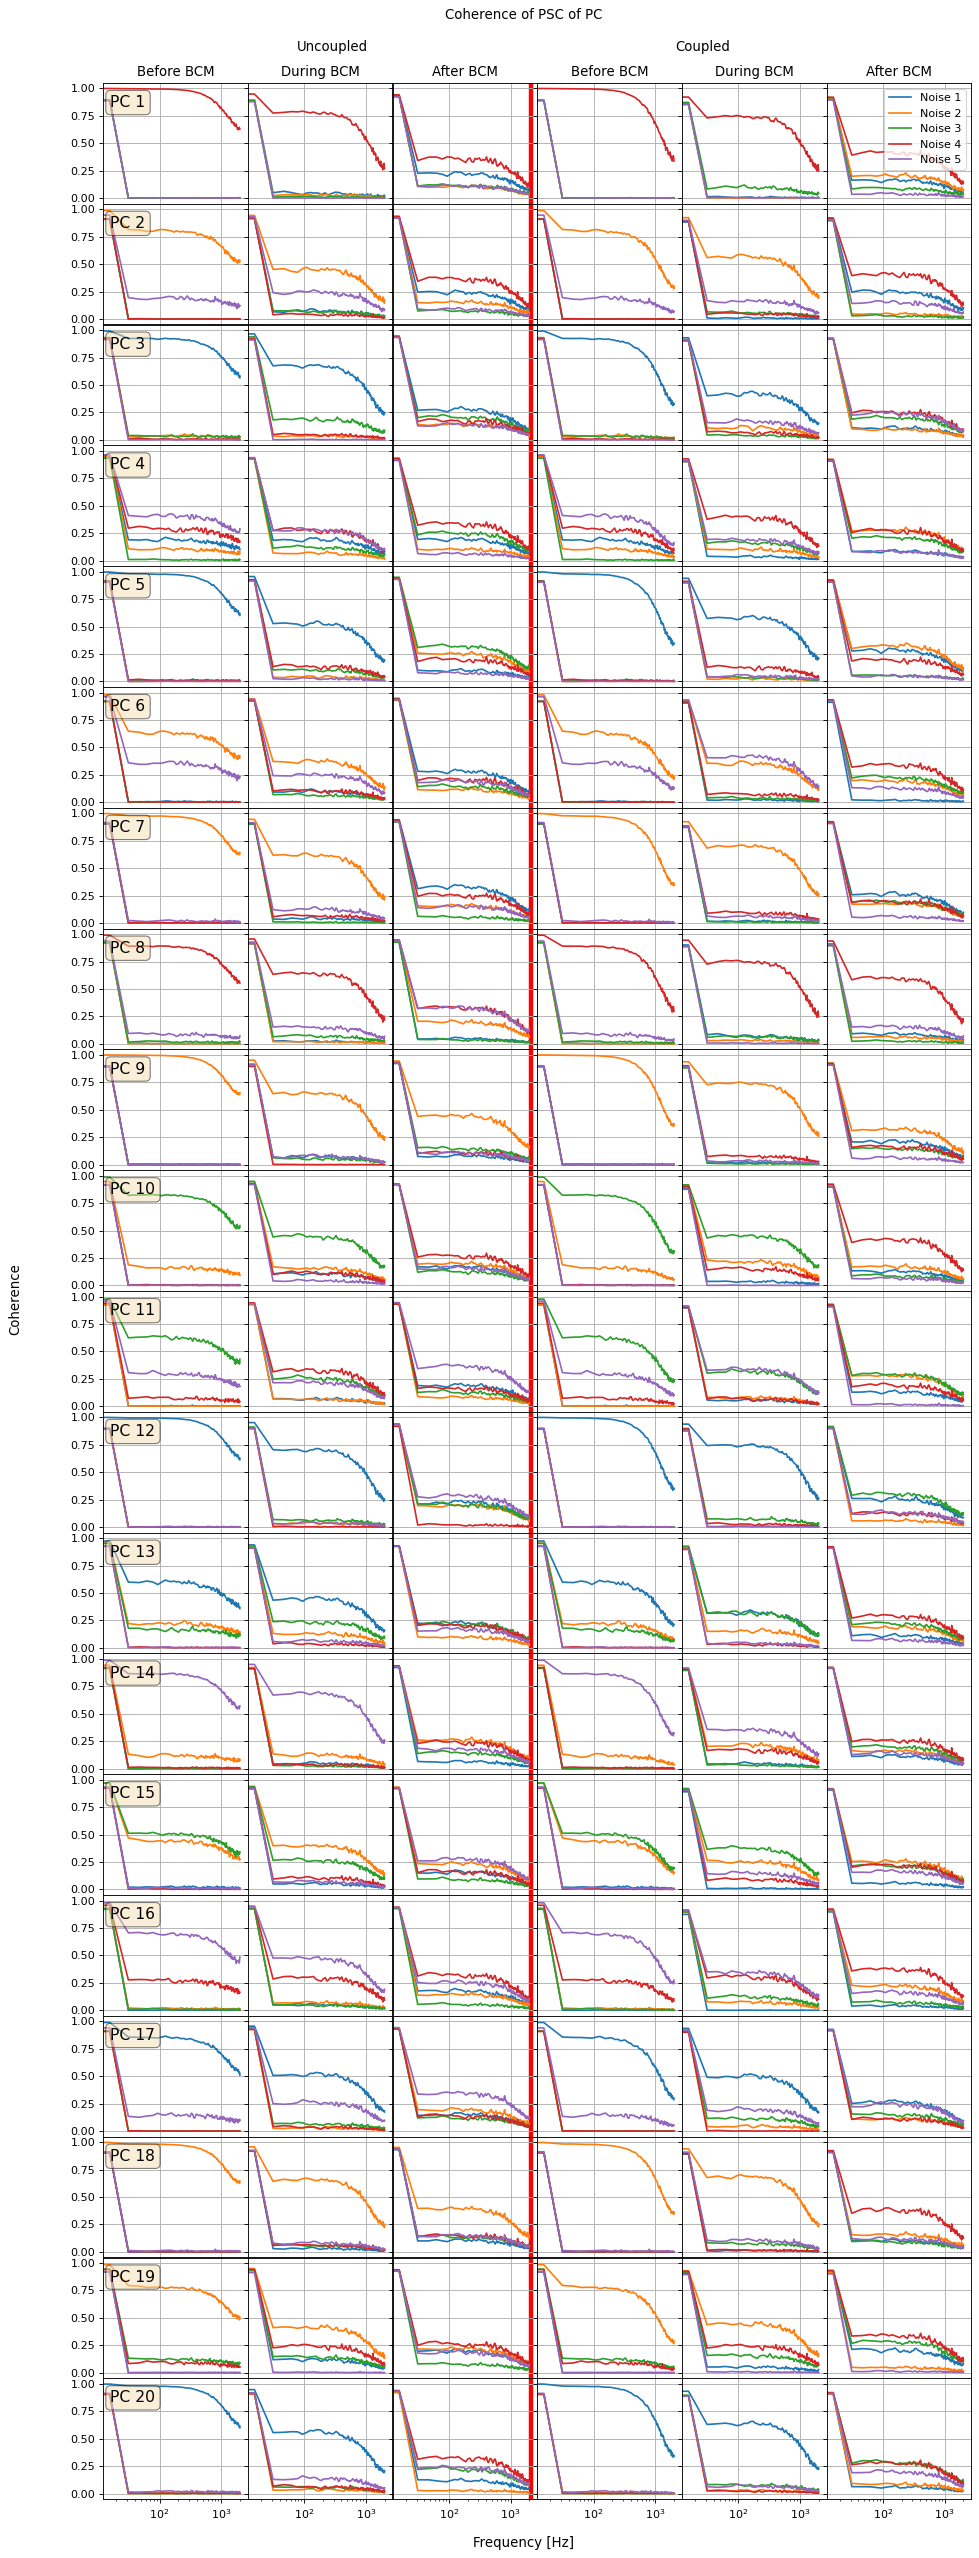

CPU times: user 27.8 s, sys: 185 ms, total: 28 s
Wall time: 28 s


In [18]:
%%time
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
fig, axs = plt.subplots(Params.N_Cells_PC,6, figsize=(14, 2*Params.N_Cells_PC), sharex=True, sharey=True, dpi= 80, facecolor='w', edgecolor='k')
fig.subplots_adjust(hspace = .001, wspace=.001)
col = 6
axs = axs.ravel()
axs[0].set_title('Before BCM')
axs[1].set_title('During BCM')
axs[2].set_title('After BCM')
axs[3].set_title('Before BCM')
axs[4].set_title('During BCM')
axs[5].set_title('After BCM')
for ii in range(0,Params.N_Cells_PC):
    for jj in range(0,Params.N_Noise):
        axs[ii*col].plot(f_No_BCM[ii][jj],cxy_No_BCM[ii][jj],label="Noise "+str(jj+1))
    axs[ii*col].set_xlabel('')
    axs[ii*col].set_xticklabels([])
    axs[ii*col].set_ylabel('')
    axs[ii*col].set_xscale('log')
    axs[ii*col].grid(True)
    axs[ii*col].text(0.05, 0.9, 'PC '+str(ii+1), transform=axs[ii*col].transAxes, fontsize=14, verticalalignment='top', bbox=props)
    for jj in range(0,Params.N_Noise):     
        axs[ii*col+1].plot(f_During_BCM[ii][jj],cxy_During_BCM[ii][jj],label="Noise "+str(jj+1))
    axs[ii*col+1].set_xticklabels([])
    axs[ii*col+1].set_ylabel('')
    axs[ii*col+1].set_xlabel('')
    axs[ii*col+1].set_xscale('log')
    axs[ii*col+1].grid(True)
    for jj in range(0,Params.N_Noise):     
        axs[ii*col+2].plot(f_BCM[ii][jj],cxy_BCM[ii][jj],label="Noise "+str(jj+1))
    axs[ii*col+2].set_xticklabels([])
    axs[ii*col+2].set_ylabel('')
    axs[ii*col+2].set_xlabel('')
    axs[ii*col+2].set_xscale('log')
    axs[ii*col+2].grid(True)
    axs[ii*col+2].axvline(x=2100,ymin=-1.2,ymax=1.2,c="red",linewidth=4,zorder=0, clip_on=True)
    for jj in range(0,Params.N_Noise):     
        axs[ii*col+3].plot(f_Coupled_No_BCM[ii][jj],cxy_Coupled_No_BCM[ii][jj],label="Noise "+str(jj+1))
    axs[ii*col+3].set_xlabel('')
    axs[ii*col+3].set_xticklabels([])
    axs[ii*col+3].set_ylabel('')
    axs[ii*col+3].set_xscale('log')
    axs[ii*col+3].grid(True)
    for jj in range(0,Params.N_Noise):     
        axs[ii*col+4].plot(f_Coupled_During_BCM[ii][jj],cxy_Coupled_During_BCM[ii][jj],label="Noise "+str(jj+1))
    axs[ii*col+4].set_xticklabels([])
    axs[ii*col+4].set_ylabel('')
    axs[ii*col+4].set_xlabel('')
    axs[ii*col+4].set_xscale('log')
    axs[ii*col+4].grid(True)
    for jj in range(0,Params.N_Noise):     
        axs[ii*col+5].plot(f_Coupled_BCM[ii][jj],cxy_Coupled_BCM[ii][jj],label="Noise "+str(jj+1))
    axs[ii*col+5].set_xticklabels([])
    axs[ii*col+5].set_ylabel('')
    axs[ii*col+5].set_xlabel('')
    axs[ii*col+5].set_xscale('log')
    axs[ii*col+5].grid(True)
    axs[col-1].legend(loc='upper right')
fig.text(0.5, 0.9, 'Coherence of PSC of PC', ha='center', rotation='horizontal', fontsize='large')
fig.text(0.33, 0.89, 'Uncoupled', ha='center', rotation='horizontal', fontsize='large')
fig.text(0.66, 0.89, 'Coupled', ha='center', rotation='horizontal', fontsize='large')
fig.text(0.04, 0.5, 'Coherence', va='center', rotation='vertical', fontsize='large')
fig.text(0.5, 0.11, 'Frequency [Hz]', ha='center', rotation='horizontal', fontsize='large')
plt.ylim([-0.05, 1.05])
plt.show()

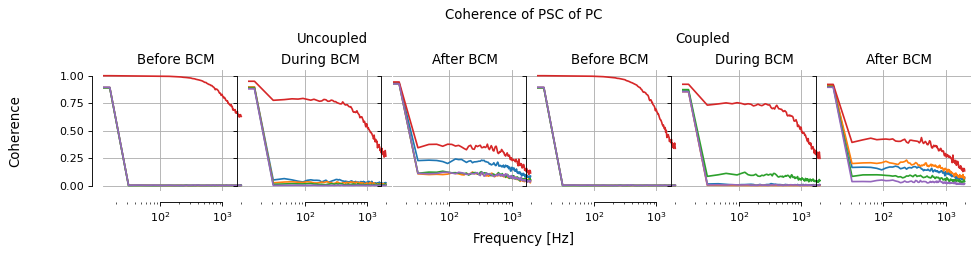

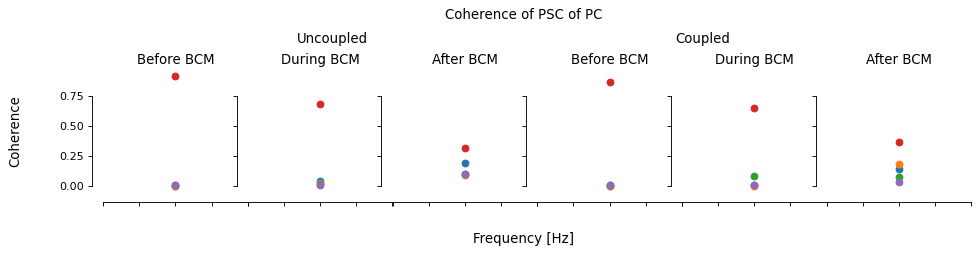

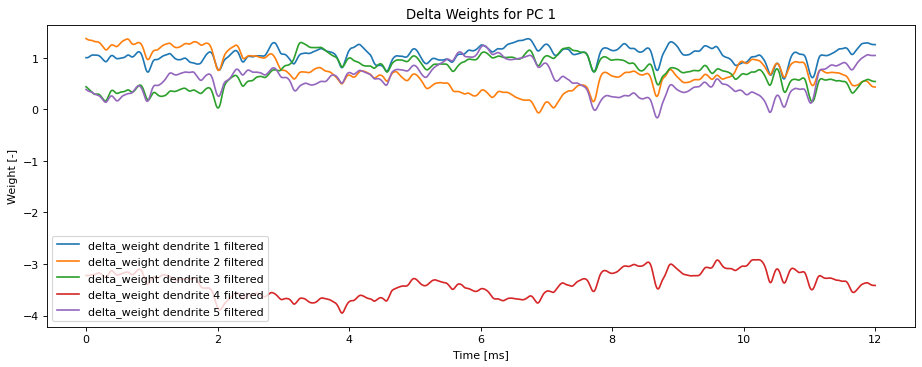

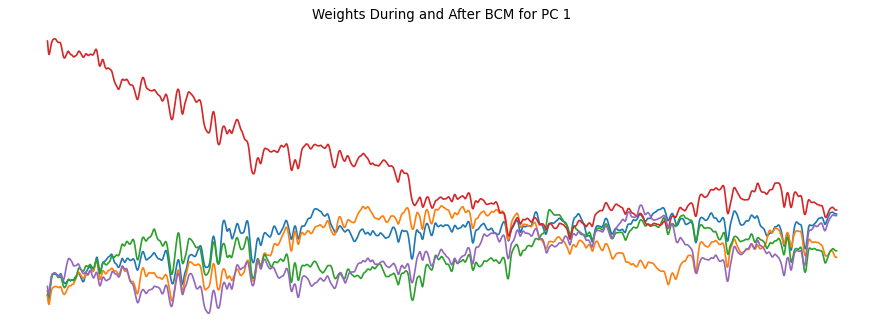

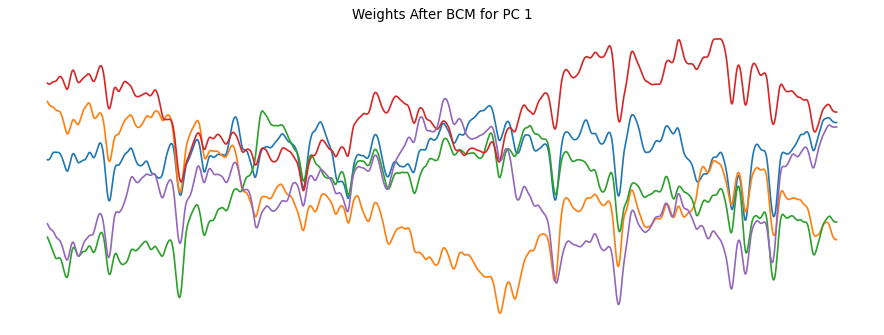

In [39]:
ii = 0
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
fig, axs = plt.subplots(1,6, figsize=(14, 2), sharex=True, sharey=True, dpi= 80, facecolor='w', edgecolor='k')
fig.subplots_adjust(hspace = .001, wspace=.001)
col = 0
axs = axs.ravel()
axs[0].set_title('Before BCM')
axs[1].set_title('During BCM')
axs[2].set_title('After BCM')
axs[3].set_title('Before BCM')
axs[4].set_title('During BCM')
axs[5].set_title('After BCM')
for jj in range(0,Params.N_Noise):
    axs[col].plot(f_No_BCM[ii][jj],cxy_No_BCM[ii][jj],label="Noise "+str(jj+1))
axs[col].set_xlabel('')
axs[col].set_xticklabels([])
axs[col].set_ylabel('')
axs[col].set_xscale('log')
axs[col].grid(True)
# axs[col].text(0.05, 0.9, 'PC '+str(ii+1), transform=axs[ii*col].transAxes, fontsize=14, verticalalignment='top', bbox=props)
for jj in range(0,Params.N_Noise):     
    axs[col+1].plot(f_During_BCM[ii][jj],cxy_During_BCM[ii][jj],label="Noise "+str(jj+1))
axs[col+1].set_xticklabels([])
axs[col+1].set_ylabel('')
axs[col+1].set_xlabel('')
axs[col+1].set_xscale('log')
axs[col+1].grid(True)
for jj in range(0,Params.N_Noise):     
    axs[col+2].plot(f_BCM[ii][jj],cxy_BCM[ii][jj],label="Noise "+str(jj+1))
axs[col+2].set_xticklabels([])
axs[col+2].set_ylabel('')
axs[col+2].set_xlabel('')
axs[col+2].set_xscale('log')
axs[col+2].grid(True)
# axs[col+2].axvline(x=2100,ymin=-1.5,ymax=1.5,c="red",linewidth=4,zorder=0, clip_on=True)
for jj in range(0,Params.N_Noise):     
    axs[col+3].plot(f_Coupled_No_BCM[ii][jj],cxy_Coupled_No_BCM[ii][jj],label="Noise "+str(jj+1))
axs[col+3].set_xlabel('')
axs[col+3].set_xticklabels([])
axs[col+3].set_ylabel('')
axs[col+3].set_xscale('log')
axs[col+3].grid(True)
for jj in range(0,Params.N_Noise):     
    axs[col+4].plot(f_Coupled_During_BCM[ii][jj],cxy_Coupled_During_BCM[ii][jj],label="Noise "+str(jj+1))
axs[col+4].set_xticklabels([])
axs[col+4].set_ylabel('')
axs[col+4].set_xlabel('')
axs[col+4].set_xscale('log')
axs[col+4].grid(True)
for jj in range(0,Params.N_Noise):     
    axs[col+5].plot(f_Coupled_BCM[ii][jj],cxy_Coupled_BCM[ii][jj],label="Noise "+str(jj+1))
axs[col+5].set_xticklabels([])
axs[col+5].set_ylabel('')
axs[col+5].set_xlabel('')
axs[col+5].set_xscale('log')
axs[col+5].grid(True)
# axs[col-1].legend(loc='upper right')
fig.text(0.5, 1.2, 'Coherence of PSC of PC', ha='center', rotation='horizontal', fontsize='large')
fig.text(0.33, 1.05, 'Uncoupled', ha='center', rotation='horizontal', fontsize='large')
fig.text(0.66, 1.05, 'Coupled', ha='center', rotation='horizontal', fontsize='large')
fig.text(0.04, 0.5, 'Coherence', va='center', rotation='vertical', fontsize='large')
fig.text(0.5, -0.2, 'Frequency [Hz]', ha='center', rotation='horizontal', fontsize='large')
plt.ylim([-0.05, 1.05])
sns.despine(offset=10, trim=True)
plt.show()



        
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
fig, axs = plt.subplots(1,6, figsize=(14, 2), sharex=True, sharey=True, dpi= 80, facecolor='w', edgecolor='k')
fig.subplots_adjust(hspace = .001, wspace=.001)
col = 0
axs = axs.ravel()
axs[0].set_title('Before BCM')
axs[1].set_title('During BCM')
axs[2].set_title('After BCM')
axs[3].set_title('Before BCM')
axs[4].set_title('During BCM')
axs[5].set_title('After BCM')
for jj in range(0,Params.N_Noise):
    axs[col].scatter([1],mean_point_cxy_No_BCM[ii][jj],label="Noise "+str(jj+1))
axs[col].set_xlabel('')
axs[col].set_xticklabels([])
axs[col].set_ylabel('')
# axs[col].text(0.05, 0.9, 'PC '+str(ii+1), transform=axs[ii*col].transAxes, fontsize=14, verticalalignment='top', bbox=props)
for jj in range(0,Params.N_Noise):     
    axs[col+1].scatter([1],mean_point_cxy_During_BCM[ii][jj],label="Noise "+str(jj+1))
axs[col+1].set_xticklabels([])
axs[col+1].set_ylabel('')
axs[col+1].set_xlabel('')
for jj in range(0,Params.N_Noise):     
    axs[col+2].scatter([1],mean_point_cxy_BCM[ii][jj],label="Noise "+str(jj+1))
axs[col+2].set_xticklabels([])
axs[col+2].set_ylabel('')
axs[col+2].set_xlabel('')
# axs[col+2].axvline(x=2100,ymin=-1.5,ymax=1.5,c="red",linewidth=4,zorder=0, clip_on=True)
for jj in range(0,Params.N_Noise):     
    axs[col+3].scatter([1],mean_point_cxy_Coupled_No_BCM[ii][jj],label="Noise "+str(jj+1))
axs[col+3].set_xlabel('')
axs[col+3].set_xticklabels([])
axs[col+3].set_ylabel('')
for jj in range(0,Params.N_Noise):     
    axs[col+4].scatter([1],mean_point_cxy_Coupled_During_BCM[ii][jj],label="Noise "+str(jj+1))
axs[col+4].set_xticklabels([])
axs[col+4].set_ylabel('')
axs[col+4].set_xlabel('')
for jj in range(0,Params.N_Noise):     
    axs[col+5].scatter([1],mean_point_cxy_Coupled_BCM[ii][jj],label="Noise "+str(jj+1))
axs[col+5].set_xticklabels([])
axs[col+5].set_ylabel('')
axs[col+5].set_xlabel('')
fig.text(0.5, 1.2, 'Coherence of PSC of PC', ha='center', rotation='horizontal', fontsize='large')
fig.text(0.33, 1.05, 'Uncoupled', ha='center', rotation='horizontal', fontsize='large')
fig.text(0.66, 1.05, 'Coupled', ha='center', rotation='horizontal', fontsize='large')
fig.text(0.04, 0.5, 'Coherence', va='center', rotation='vertical', fontsize='large')
fig.text(0.5, -0.2, 'Frequency [Hz]', ha='center', rotation='horizontal', fontsize='large')
plt.xlim([0,2])
sns.despine(offset=10, trim=True)
plt.show()


kk = 0
fs = 1/(Params.dt/second)  # Sampling frequency
plt.figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
for jj in range(ii*Params.N_Noise,(ii+1)*Params.N_Noise):  
    t = np.arange(len(mon_N_PC_BCM.delta_weight[jj][len(mon_N_PC_BCM.delta_weight[jj])//2:]))/fs
    signala = mon_N_PC_BCM.delta_weight[jj][len(mon_N_PC_BCM.delta_weight[jj])//2:] # with frequency of 100
    fc = 5  # Cut-off frequency of the filter
    w = fc / (fs / 2) # Normalize the frequency
    b, a = signal.butter(2, w, 'low')
    output = signal.filtfilt(b, a, signala)
    plt.plot(t, output, label="delta_weight dendrite "+str(kk+1)+' filtered')
    kk += 1
ylabel('Weight [-]')
xlabel('Time [ms]')
title('Delta Weights for PC '+str(ii+1))
legend(loc='lower left')
show()

kk = 0
plt.figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
for jj in range(ii*Params.N_Noise,(ii+1)*Params.N_Noise):   
    t = np.arange(len(mon_N_PC_BCM.new_weight[jj]))/fs
    signala = mon_N_PC_BCM.new_weight[jj] # with frequency of 100
    fc = 5  # Cut-off frequency of the filter
    w = fc / (fs / 2) # Normalize the frequency
    b, a = signal.butter(2, w, 'low')
    output = signal.filtfilt(b, a, signala)
    plt.plot(t, output, label="new_weight dendrite "+str(kk+1)+' filtered')
    kk += 1
ylabel('Weight [-]')
xlabel('Time [ms]')
title('Weights During and After BCM for PC '+str(ii+1))
# legend(loc='upper right')
plt.axis('off')
show()

kk = 0
plt.figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
for jj in range(ii*Params.N_Noise,(ii+1)*Params.N_Noise):   
    t = np.arange(len(mon_N_PC_BCM.new_weight[jj][len(mon_N_PC_BCM.new_weight[jj])//2:]))/fs
    signala = mon_N_PC_BCM.new_weight[jj][len(mon_N_PC_BCM.new_weight[jj])//2:] # with frequency of 100
    fc = 5  # Cut-off frequency of the filter
    w = fc / (fs / 2) # Normalize the frequency
    b, a = signal.butter(2, w, 'low')
    output = signal.filtfilt(b, a, signala)
    plt.plot(t, output, label="new_weight dendrite "+str(kk+1)+' filtered')
    kk += 1
ylabel('Weight [-]')
xlabel('Time [ms]')
title('Weights After BCM for PC '+str(ii+1))
# legend(loc='upper right')
sns.despine(offset=10, trim=True)
plt.axis('off')
show()

In [20]:
def highlight_col(x):
    r = 'background-color: yellow'
    df1 = pd.DataFrame('', index=x.index, columns=x.columns)
    df1.iloc[-1, [0,1]] = r
    return df1    

var = [[]]*Params.N_Noise 
var_Coupled = [[]]*Params.N_Noise 
pair_diff = [[]]*Params.N_Noise 
pair_diff_Coupled = [[]]*Params.N_Noise 
for ii in range(0,Params.N_Noise):
    var[ii] = [[]]*Params.N_Cells_PC
    var_Coupled[ii] = [[]]*Params.N_Cells_PC
    pair_diff[ii] = [[]]*Params.N_Cells_PC
    pair_diff_Coupled[ii] = [[]]*Params.N_Cells_PC
    for jj in range(0,Params.N_Cells_PC):
        var[ii][jj] = variance([mean_point_cxy_No_BCM[jj][ii],mean_point_cxy_BCM[jj][ii]])
        var_Coupled[ii][jj] = variance([mean_point_cxy_Coupled_No_BCM[jj][ii],mean_point_cxy_Coupled_BCM[jj][ii]])
        pair_diff[ii][jj] = mean_point_cxy_No_BCM[jj][ii]-mean_point_cxy_BCM[jj][ii]
        pair_diff_Coupled[ii][jj] = mean_point_cxy_Coupled_No_BCM[jj][ii]-mean_point_cxy_Coupled_BCM[jj][ii]

PC_index = []
PC_index_pair = []
for ii in range(0,Params.N_Cells_PC):
    PC_index.append('PC '+str(ii+1))
    PC_index_pair.append('PC '+str(ii+1))
PC_index.append('Mean Variance')
PC_index_pair.append('Mean Pairwise difference')



Noise_index = []    
for ii in range(0,Params.N_Noise):
    Noise_index.append('Source  '+str(ii+1))
    
data = []  
data_Coupled = []    
data_pair = []    
data_pair_Coupled = []    
for ii in range(0,len(var)):
    data.append(var[ii])
    data_Coupled.append(var_Coupled[ii])
    data_pair.append(pair_diff[ii])
    data_pair_Coupled.append(pair_diff_Coupled[ii])
    
data_1 = data
mean_var = []
data_pair_1 = data_pair
mean_pair_diff = []
data_1_Coupled = data_Coupled
mean_var_Coupled = []
data_pair_1_Coupled = data_pair_Coupled
mean_pair_diff_Coupled = []
for ii in range(0,len(data)):
    mean_var.append(mean(data[ii]))
    data_1[ii].append(mean(data[ii]))
    mean_pair_diff.append(mean(data_pair[ii]))
    data_pair_1[ii].append(mean(data_pair[ii]))
    mean_var_Coupled.append(mean(data_Coupled[ii]))
    data_1_Coupled[ii].append(mean(data_Coupled[ii]))
    mean_pair_diff_Coupled.append(mean(data_pair_Coupled[ii]))
    data_pair_1_Coupled[ii].append(mean(data_pair_Coupled[ii]))


    
    
df1 = pd.DataFrame(transpose(data_1), index = PC_index, columns = Noise_index)

cm = sns.light_palette("red", as_cmap=True)

df1.style.background_gradient(cmap='viridis')


,Source 1,Source 2,Source 3,Source 4,Source 5
PC 1,0.018557,0.004234,0.004847,0.184040,0.004580
PC 2,0.021541,0.188448,0.001880,0.051982,0.004828
PC 3,0.189748,0.003998,0.011054,0.010246,0.007074
PC 4,0.000017,0.000027,0.022430,0.000352,0.053920
PC 5,0.338298,0.024696,0.036474,0.013374,0.002113
PC 6,0.028479,0.119019,0.007611,0.016344,0.013663
PC 7,0.040379,0.292960,0.001005,0.024200,0.006426
PC 8,0.000712,0.015330,0.000085,0.142971,0.021571
PC 9,0.002277,0.139850,0.007861,0.004246,0.004332
PC 10,0.010291,0.000302,0.216787,0.027405,0.009471


In [21]:
def highlight_max(s):
    if s.dtype == np.object:
        is_neg = [False for _ in range(s.shape[0])]
    else:
        is_neg = s < 0
    return ['color: red;' if cell else 'color:black' 
            for cell in is_neg]

df2 = pd.DataFrame(transpose(data_pair_1), index = PC_index_pair, columns = Noise_index)
df2.style.apply(highlight_max)

,Source 1,Source 2,Source 3,Source 4,Source 5
PC 1,-0.192648,-0.092024,-0.098455,0.606695,-0.095706
PC 2,-0.207563,0.613919,-0.061325,-0.322436,0.098261
PC 3,0.616032,-0.089420,-0.148689,-0.143150,-0.118943
PC 4,0.005843,0.007407,-0.211802,-0.026543,0.328389
PC 5,0.822554,-0.222242,-0.270091,-0.163551,-0.065004
PC 6,-0.238658,0.487892,-0.123379,-0.180801,0.165308
PC 7,-0.284178,0.765454,-0.044832,-0.219998,-0.113369
PC 8,-0.037736,-0.175102,-0.013040,0.534735,-0.207707
PC 9,-0.067479,0.528866,-0.125384,-0.092157,-0.093082
PC 10,-0.143465,-0.024557,0.658464,-0.234113,-0.137630


In [22]:
df3 = pd.DataFrame(transpose(data_pair_1_Coupled), index = PC_index_pair, columns = Noise_index)
df3.style.apply(highlight_max)

,Source 1,Source 2,Source 3,Source 4,Source 5
PC 1,-0.141010,-0.181324,-0.074162,0.501877,-0.031788
PC 2,-0.212146,0.662551,-0.022237,-0.359512,0.034564
PC 3,0.710471,-0.051462,-0.145357,-0.217296,-0.209004
PC 4,0.088962,-0.155731,-0.176090,0.014721,0.288841
PC 5,0.605290,-0.288118,-0.035873,-0.161706,-0.042126
PC 6,-0.009476,0.380769,-0.195982,-0.297669,0.198961
PC 7,-0.228375,0.692025,-0.168755,-0.166898,-0.032706
PC 8,-0.073418,-0.052564,-0.005019,0.246893,-0.062646
PC 9,-0.180898,0.579751,-0.125244,-0.139915,-0.052575
PC 10,-0.107164,-0.009875,0.646562,-0.366197,-0.055465


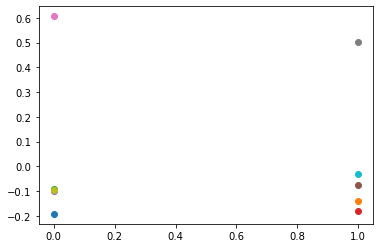

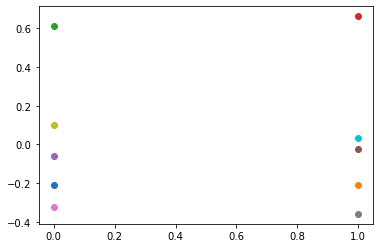

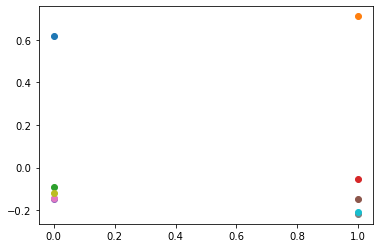

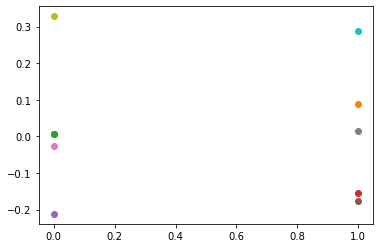

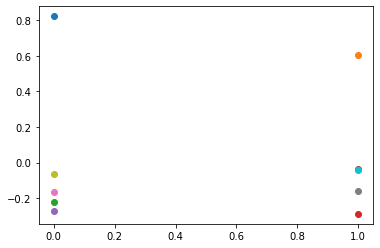

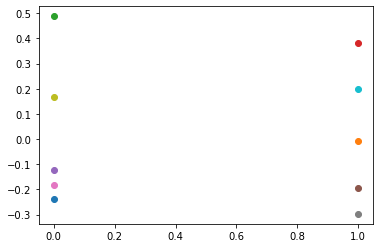

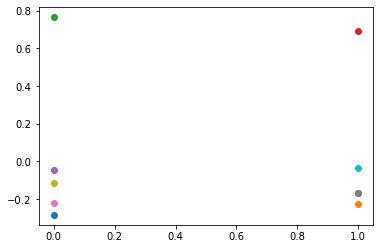

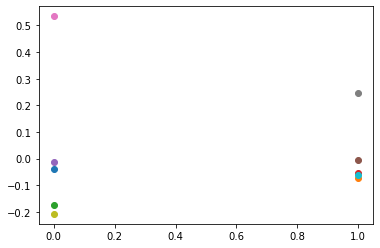

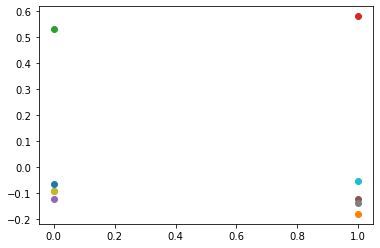

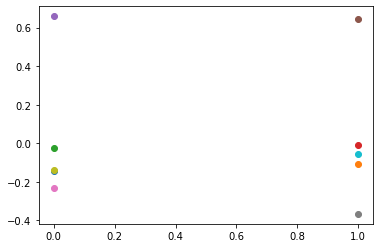

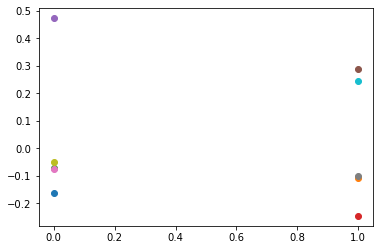

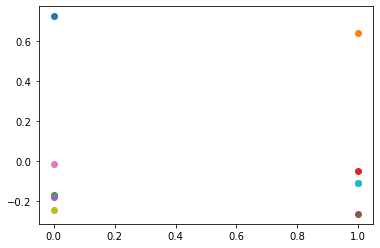

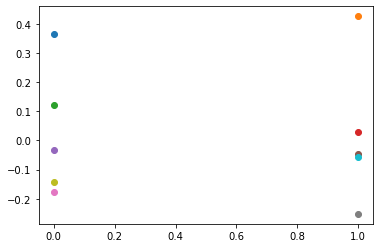

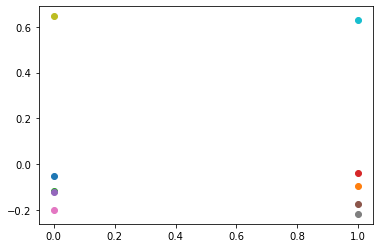

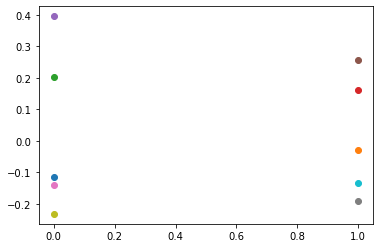

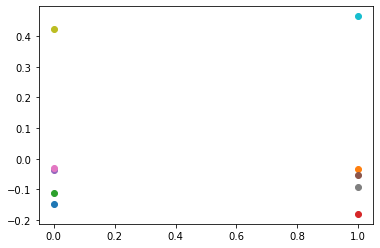

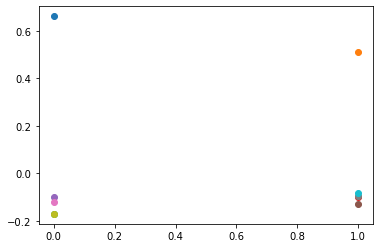

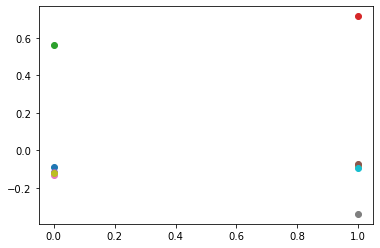

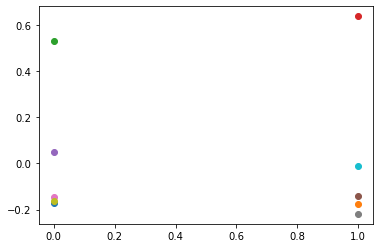

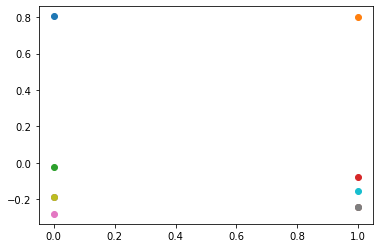

In [23]:
for ii in range(0,Params.N_Cells_PC):
    for jj in range(0,Params.N_Noise):
        scatter([0],transpose(data_pair)[ii][jj],label="Noise "+str(jj+1))
        scatter([1],transpose(data_pair_Coupled)[ii][jj],label="Noise "+str(jj+1))
    show()